In [10]:
import pandas as pd
import numpy as np
import glob
import os
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Tasks to clean:
    - Demographics -- DONE
    - Expertise Survey -- DONE
    - Expertise Survey 2 (games played) -- DONE
    - Pokemon Name Task -- DONE
    - Visual Task -- DONE
        - Block 1 -- DONE
        - Block 2 -- DONE
    - Auditory Task -- DONE
        - Block 1 -- DONE
        - Block 2 -- DONE
    - Pattern Comparison Task -- DONE
        - Block 1 -- DONE
        - Block 2 -- DONE
    - Lettersets - DONE
    - Number Series - DONE

### Need to return to this once accuracies are calculated to do the same for reaction times.

## Open the files and join them together

In [13]:
file_path = ("./CAPE LOCAL/full_data/")

In [14]:
all_files = glob.glob(os.path.join(file_path, "*.csv"))

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

In [15]:
# Add the participant ID to all rows.
df['participant_id'] = df['participant_id'].ffill()

In [16]:
# time_render
# time_end
# time_end - time_render = reactio_time
# np.where will be used to get the reaction time for a given task

# average over all auditory
# average over pokemon auditory
# average over animal auditory
# pokemon over all visual
# average over pokemon visual
# average over animal visual

## Clean the expertise survey

In [17]:
df['age_first_movie'] = np.where(df['sender'] == 'Expertise Survey',
                                 df['age'],
                                 np.nan)

In [18]:
# Join the data from the google form csv with the same column names.

expertise_df = pd.read_csv('Pokemon Expertise Survey.csv')
expertise_df.drop(columns=['Username'], inplace=True)

expertise_df.columns = ['Timestamp', 'participant_id', 'pokemon_interest', 'pokemon_knowledge',
                        'watched_movies_tv', 'movie_tv_multiple', 'movie_tv_number', 'age_first_movie',
                        'played_pokemon_games', 'played_multiple_times', 'played_number_times', 
                        'years_since_first_game', 'favorite_pokemon', 'fav_gen', 'follow_socials',
                        'engage_weekly', 'collect_trading_cards', 'years_collecting_cards',
                        'play_competitively', 'years_play_competitively', 'all_games_played']

In [19]:
expertise_df['all_games_played'] = expertise_df['all_games_played'].apply(lambda x: x.replace(" ", "_"))
expertise_df['all_games_played'] = expertise_df['all_games_played'].apply(lambda x: x.split(';'))

In [20]:
ex_df2 = expertise_df.copy()
ex_df2.set_index('participant_id',inplace=True)
expertise_dict = ex_df2.to_dict()['all_games_played']

## Clean the Name Recognition Test

In [21]:
mask = (df['sender'] == 'Pokémon Name Recognition Test')

for pokemon_column in ['Abra' , 'Bulbasaur' , 'Charizard' , 'Ditto',
                       'Dodrio' , 'Dragonite' , 'Eevee' , 'Electrode',
                       'goldeen' , 'Golbat' , 'Horsea' , 'Jigglypuff',
                       'Jynx' , 'Koffing' , 'Muk' , 'Pikachu',
                       'Pinsir' , 'Poliwrath' , 'Ponyta' , 'Psyduck',
                       'Scyther' , 'Seel' , 'Snorlax' , 'Staryu' , 'Tangela',
                       'Astax' , 'Birdrum' , 'Brustum' , 'Blitzbug',
                       'Crylax' , 'Dastardo' , 'Fluritzee' , 'Frogert',
                       'Fwooshy' , 'Gargooey' , 'Gumy' , 'Koaleon',
                       'Loffitoff' , 'Loopinsy' , 'Munkeezy' , 'Oxston',
                       'Postorph', 'Quix' , 'Ramstar' , 'Sheepo' , 'Spish',
                       'Tungstroy' , 'Vibeast' , 'Vitrion' , 'Yipster']:
    
    df.loc[mask, pokemon_column] = df.loc[mask, pokemon_column].fillna(value=False)

In [22]:
# Calculate the total correct real names and the incorrect fake names each into new columns.
df['real_names_correct'] = df['Abra'] + df['Bulbasaur'] + df['Charizard'] + df['Ditto'] \
                           + df['Dodrio'] + df['Dragonite'] + df['Eevee'] + df['Electrode'] \
                           + df['goldeen'] + df['Golbat'] + df['Horsea'] + df['Jigglypuff'] \
                           + df['Jynx'] + df['Koffing'] + df['Muk'] + df['Pikachu'] \
                           + df['Pinsir'] + df['Poliwrath'] + df['Ponyta'] + df['Psyduck'] \
                           + df['Scyther'] + df['Seel'] + df['Snorlax'] + df['Staryu'] + df['Tangela']
    
df['fake_names_incorrect'] = df['Astax'] + df['Birdrum'] + df['Brustum'] + df['Blitzbug'] \
                             + df['Crylax'] + df['Dastardo'] + df['Fluritzee'] + df['Frogert'] \
                             + df['Fwooshy'] + df['Gargooey'] + df['Gumy'] + df['Koaleon']\
                             + df['Loffitoff'] + df['Loopinsy'] + df['Munkeezy'] + df['Oxston']\
                             + df['Postorph']+ df['Quix'] + df['Ramstar'] + df['Sheepo'] + df['Spish']\
                             + df['Tungstroy'] + df['Vibeast'] + df['Vitrion'] + df['Yipster'] 
                             

## Clean the trivia questions

In [23]:
# Score the trivia questions - compare correct answers to responded answer.

df = df.assign(trivia_correct=0)

correct_trivia_ans = ['responded_answer3', 'responded_answer1', 'responded_answer4', 'responded_answer3',
                      'responded_answer3', 'responded_answer2', 'responded_answer4', 'responded_answer4',
                      'responded_answer2', 'responded_answer1', 'responded_answer3', 'responded_answer2', 
                      'responded_answer4', 'responded_answer1', 'responded_answer2', 'responded_answer3',
                      'responded_answer2', 'responded_answer2', 'responded_answer1', 'responded_answer1',
                      'responded_answer4', 'responded_answer3', 'responded_answer1', 'responded_answer4', 
                      'responded_answer2']

for trivia_num, trivia_ans in list(zip(range(1,26), correct_trivia_ans)):
    
    df['trivia_correct'] = np.where(( (df["sender"] == 'Knowledge Question Screen') \
                                     & (df["question_num"] == float(trivia_num)) \
                                     & (df['response'] == trivia_ans)) \
                                     | (df['trivia_correct'] == 1),
                                                          1,
                                                          0)

In [24]:
## Riley Change 2026-02-03: Added reaction time

df['trivia_reaction_time'] = (np.where(df['trivia_correct'] == 1,
                                       (df['time_end'] - df['time_render'])/1000,
                                       np.nan))

## Clean the visual task

In [25]:
# Score the visual task responses. 

df = df.assign(visual_correct=0)

df['prev_screen'] = df["sender"].shift(1)
df['two_prev_screen'] = df["sender"].shift(2)
df['three_prev_screen'] = df["sender"].shift(3)
df['next_screen'] = df["sender"].shift(-1)

correct_visual_ans = {'131.png':'box1', '12.png':'box5', '136.png':'box1', '34.png':'box2', '11.png':'box5', 
                      'horse_4.jpg':'box4', '93.png':'box2', 'cricket_4.jpg':'box4', 'frog_2.jpg':'box2', 
                      '42.png':'box5', '85.png':'box5', '4.png':'box2', '13.png':'box6', '99.png':'box4',
                       '10.png':'box6', '50.png':'box5', '38.png':'box4', '76.png':'box6', '41.png':'box2', 
                      '23.png':'box5', '27.png':'box5', '62.png':'box3', '96.png':'box5', '138.png':'box5', 
                      '84.png':'box5', 'pig_3.jpg':'box1', '24.png':'box2', 'monkey_5.jpg':'box5',
                      'bee_6.jpg':'box1', '151.png':'box2', '106.png':'box6', '112.png':'box4', 
                      '98.png':'box4', '139.png':'box1', '89.png':'box6', '21.png':'box1', 
                      'birds_2.jpg':'box1', 'chicken_1.jpg':'box6', '2.png':'box3', '48.png':'box2', 
                      '55.png':'box2', '52.png':'box2', 'duck_8.jpg':'box3', '135.png':'box3', 
                      'sheep_2.jpg':'box4', '101.png':'box2', '77.png':'box6', '122.png':'box4', 
                      '58.png':'box2', '71.png':'box5', 
                      'dog_5.jpg':'box3', '20.png':'box1', '3.png':'box5', '69.png':'box3', '111.png':'box2', 
                      '110.png':'box3', '142.png':'box1', 'lion_2.jpg':'box1', '43.png':'box1', 
                      '32.png':'box3', 'elephant_5.jpg':'box4', '121.png':'box5', '127.png':'box6', 
                      'turkey_6.jpg':'box5', 'bear_2.jpg':'box1', '36.png':'box3', 'owl_4.jpg':'box4', 
                      'cat_1.jpg':'box2', '17.png':'box5', '134.png':'box1', '130.png':'box3', 
                      '107.png':'box2', '9.png':'box1', '63.png':'box3', '5.png':'box2', '49.png':'box3', 
                      '1.png':'box4', '125.png':'box2', 'cow_3.jpg':'box5', '88.png':'box1', '26.png':'box2',
                       '61.png':'box4', '145.png':'box6', '7.png':'box1', '72.png':'box4', '124.png':'box5',
                       'donkey_4.jpg':'box3', '81.png':'box4', '129.png':'box3', 'tiger_3.jpg':'box1', 
                      '146.png':'box3', '116.png':'box2', '140.png':'box3', '56.png':'box5', '25.png':'box2',
                       '150.png':'box5', '64.png':'box4', '97.png':'box4', '16.png':'box5', '113.png':'box4'}

for key, value in correct_visual_ans.items():
    
    df['visual_correct'] = np.where(( (df["sender"] == 'Response Screen') \
                                     & (df["poke_image"] == key) \
                                     & (df['response'] == value)) \
                                     | (df['visual_correct'] == 1),
                                                          1,
                                                          0)

In [26]:
animals_image_list = ['horse_4.jpg', 'cricket_4.jpg', 'frog_2.jpg', 'pig_3.jpg', 'monkey_5.jpg',
                      'bee_6.jpg', 'birds_2.jpg', 'chicken_1.jpg', 'duck_8.jpg', 'sheep_2.jpg',
                      'dog_5.jpg', 'lion_2.jpg', 'elephant_5.jpg', 'turkey_6.jpg', 'bear_2.jpg',
                      'owl_4.jpg','cat_1.jpg', 'cow_3.jpg', 'donkey_4.jpg', 'tiger_3.jpg']

In [27]:
pokemon_image_list = ['131.png', '12.png', '136.png', '34.png', '11.png', '93.png', '42.png', '85.png',
                      '4.png', '13.png', '99.png', '10.png', '50.png', '38.png', '76.png', '41.png',
                      '23.png', '27.png', '62.png', '96.png', '138.png', '84.png', '24.png', '21.png',
                      '89.png', '139.png', '98.png', '112.png', '106.png', '151.png', '2.png', '48.png',
                      '55.png','52.png', '135.png', '101.png', '77.png', '122.png', '58.png', '71.png',
                      '20.png','3.png','69.png','111.png','110.png','142.png', '43.png', '32.png',
                      '121.png','127.png', '36.png','17.png','134.png','130.png','107.png','9.png',
                      '63.png','5.png','49.png','1.png','125.png', '88.png', '26.png','61.png','145.png',
                      '7.png','72.png','124.png','81.png','129.png','146.png','116.png','140.png',
                      '56.png','25.png','150.png','64.png','97.png','16.png','113.png']

In [28]:
## Riley Change 2026-02-03: Changed np.nan to None due to error

df['visual_trial_type'] = np.where( df['poke_image'].isin(animals_image_list),
                                    'animal trial',
                                    np.where(df['poke_image'].isin(pokemon_image_list),
                                             'pokemon trial',
                                             None))

In [29]:
# Get the blocks for the visual task.

df['visual_block'] = np.where( (df["sender"] == 'Response Screen') \
                               & (df["prev_screen"] == 'Pokemon Image Screen') \
                               & (df['response'].notnull()) \
                               & (df["three_prev_screen"] == 'Visual Instructions'),
                             1,
                                 np.where( (df["sender"] == 'Response Screen') \
                                   & (df["prev_screen"] == 'Pokemon Image Screen') \
                                   & (df['response'].notnull()) \
                                   & (df["three_prev_screen"] == 'In between blocks instruction'),
                                       2,
                                       np.where( (df["sender"] == 'Visual Loop 2') \
                                       & (df["prev_screen"] == 'Sequence') \
#                                        & (df['response'].notnull()) \
                                       & (df["next_screen"] == 'Pokemon Auditory Instructions'),
                                         0,
                                         np.nan
                                                                      )))

In [30]:
df['visual_block'] = df['visual_block'].ffill()

In [31]:
df['visual_correct_block1'] = df[df['visual_block'] == 1]['visual_correct']
df['visual_correct_block2'] = df[df['visual_block'] == 2]['visual_correct']

In [32]:
df['visual_pokemon_correct_block1'] = df[(df['visual_block'] == 1) & (df['visual_trial_type'] == 'pokemon trial')]['visual_correct']
df['visual_pokemon_correct_block2'] = df[(df['visual_block'] == 2)  & (df['visual_trial_type'] == 'pokemon trial')]['visual_correct']

In [33]:
df['visual_animal_correct_block1'] = df[(df['visual_block'] == 1) & (df['visual_trial_type'] == 'animal trial')]['visual_correct']
df['visual_animal_correct_block2'] = df[(df['visual_block'] == 2)  & (df['visual_trial_type'] == 'animal trial')]['visual_correct']

In [34]:
df['pokemon_visual_correct'] = df[df['visual_trial_type'] == 'pokemon trial']['visual_correct']
df['animal_visual_correct'] = df[df['visual_trial_type'] == 'animal trial']['visual_correct']

In [35]:
## Riley Change 2026-02-03: Added reaction time

df['overall_visual_reaction_time'] = (np.where((df['pokemon_visual_correct'] == 1) |
                                               (df['animal_visual_correct'] == 1),
                                               (df['time_end'] - df['time_render'])/1000,
                                               np.nan))

df['pokemon_visual_reaction_time'] = (np.where(df['pokemon_visual_correct'] == 1,
                                               (df['time_end'] - df['time_render'])/1000,
                                               np.nan))

df['animal_visual_reaction_time'] = (np.where(df['animal_visual_correct'] == 1,
                                              (df['time_end'] - df['time_render'])/1000,
                                              np.nan))

## Clean the auditory task

In [36]:
# Score the auditory task responses. 

df['auditory_correct'] = np.where(( (df["sender"] == 'Response Screen') \
                                     & (df["prev_screen"] == 'Pokemon Audio Screen') \
                                     & (df['response'].str.endswith('_correct'))), \
                                                          1,
                                                          0)

In [37]:
auditory_trial_list = [str(x) for x in list(range(14, 113, 2)) + list(range(115, 214, 2))]  

In [38]:
auditory_trial_type_list = ['pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'animal trial', 'animal trial', 'pokemon trial','pokemon trial','pokemon trial',
                            'animal trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'pokemon trial', 'animal trial', 'pokemon trial', 'pokemon trial','pokemon trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial', 'pokemon trial',
                            'animal trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'pokemon trial', 'animal trial', 'pokemon trial', 'animal trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial', 'pokemon trial',

                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial',
                            'pokemon trial', 'animal trial', 'animal trial', 'animal trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'animal trial', 'pokemon trial', 'animal trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'pokemon trial', 'animal trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'animal trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                            'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial', 'pokemon trial',
                           ]

In [39]:
auditory_trial_type_dict = dict(zip(auditory_trial_list, auditory_trial_type_list))

In [40]:
df['auditory_trial_type'] = df['sender_id'].map(auditory_trial_type_dict)

In [41]:
# Get the blocks for the auditory task.

df['auditory_block'] = np.where( (df["sender"] == 'Response Screen') \
                               & (df["prev_screen"] == 'Pokemon Audio Screen') \
                               & (df['response'].notnull()) \
                               & (df["two_prev_screen"] == 'Pokemon Auditory Instructions'),
                             1,
                                 np.where( (df["sender"] == 'Response Screen') \
                                   & (df["prev_screen"] == 'Pokemon Audio Screen') \
                                   & (df['response'].notnull()) \
                                   & (df["two_prev_screen"] == 'In between blocks instruction'),
                                       2,
                                       np.where( (df["sender"] == 'pattern comparison instructions 1') \
                                       & (df["prev_screen"] == 'Response Screen') \
                                       & (df['response'].notnull()) \
                                       & (df["next_screen"] == 'pattern comparison instructions 2'),
                                         0,
                                         np.nan
                                                                      )))

In [42]:
df['auditory_block'] = df['auditory_block'].ffill()

In [43]:
df['auditory_correct_block1'] = df[df['auditory_block'] == 1]['auditory_correct']
df['auditory_correct_block2'] = df[df['auditory_block'] == 2]['auditory_correct']

In [44]:
df['auditory_pokemon_correct_block1'] = df[(df['auditory_block'] == 1) & (df['auditory_trial_type'] == 'pokemon trial')]['auditory_correct']
df['auditory_pokemon_correct_block2'] = df[(df['auditory_block'] == 2)  & (df['auditory_trial_type'] == 'pokemon trial')]['auditory_correct']

In [45]:
df['auditory_animal_correct_block1'] = df[(df['auditory_block'] == 1) & (df['auditory_trial_type'] == 'animal trial')]['auditory_correct']
df['auditory_animal_correct_block2'] = df[(df['auditory_block'] == 2)  & (df['auditory_trial_type'] == 'animal trial')]['auditory_correct']

In [46]:
df['pokemon_auditory_correct'] = df[df['auditory_trial_type'] == 'pokemon trial']['auditory_correct']
df['animal_auditory_correct'] = df[df['auditory_trial_type'] == 'animal trial']['auditory_correct']

In [47]:
## Riley Change 2026-02-03: Added reaction time

df['overall_auditory_reaction_time'] = (np.where((df['pokemon_auditory_correct'] == 1) |
                                                 (df['animal_auditory_correct'] == 1),
                                                 (df['time_end'] - df['time_render'])/1000,
                                                 np.nan))

df['pokemon_auditory_reaction_time'] = (np.where(df['pokemon_auditory_correct'] == 1,
                                                 (df['time_end'] - df['time_render'])/1000,
                                                 np.nan))

df['animal_auditory_reaction_time'] = (np.where(df['animal_auditory_correct'] == 1,
                                                (df['time_end'] - df['time_render'])/1000,
                                                np.nan))

## Clean the pattern comparison task

In [48]:
# Score the pattern comparison responses. 

df = df.assign(pattern_comparison_correct=0)

correct_pattern_ans = {'stimuli_1.png':'answered_same', 'stimuli_2.png': 'answered_different', 'stimuli_3.png': 'answered_same', 
                       'stimuli_4.png': 'answered_different', 'stimuli_5.png': 'answered_same', 'stimuli_6.png': 'answered_different',
                       'stimuli_7.png': 'answered_same', 'stimuli_8.png': 'answered_different', 'stimuli_9.png': 'answered_same', 
                       'stimuli_10.png': 'answered_different', 'stimuli_11.png': 'answered_same', 'stimuli_12.png': 'answered_different',
                       'stimuli_13.png': 'answered_different', 'stimuli_14.png': 'answered_different', 'stimuli_15.png': 'answered_same',
                       'stimuli_16.png': 'answered_different', 'stimuli_17.png': 'answered_same', 'stimuli_18.png': 'answered_different',
                       'stimuli_19.png': 'answered_different', 'stimuli_20.png': 'answered_same', 'stimuli_21.png': 'answered_same',
                       'stimuli_22.png': 'answered_same', 'stimuli_23.png': 'answered_same', 'stimuli_24.png': 'answered_same',
                       'stimuli_25.png': 'answered_different', 'stimuli_26.png': 'answered_different', 'stimuli_27.png': 'answered_different',
                       'stimuli_28.png': 'answered_same', 'stimuli_29.png': 'answered_different', 'stimuli_30.png': 'answered_same',
                       'stimuli_31.png': 'answered_different', 'stimuli_32.png': 'answered_different', 'stimuli_33.png': 'answered_same', 
                       'stimuli_34.png': 'answered_same', 'stimuli_35.png': 'answered_same', 'stimuli_36.png': 'answered_same',
                       'stimuli_37.png': 'answered_different', 'stimuli_38.png': 'answered_different', 'stimuli_39.png': 'answered_same',
                       'stimuli_40.png': 'answered_same', 'stimuli_41.png': 'answered_different', 'stimuli_42.png': 'answered_different',
                       'stimuli_43.png': 'answered_same', 'stimuli_44.png': 'answered_different', 'stimuli_45.png': 'answered_different',
                       'stimuli_46.png': 'answered_different', 'stimuli_47.png': 'answered_same', 'stimuli_48.png': 'answered_same',
                       'stimuli_49.png': 'answered_same', 'stimuli_50.png': 'answered_same', 'stimuli_51.png': 'answered_same',
                       'stimuli_52.png': 'answered_different', 'stimuli_53.png': 'answered_different', 'stimuli_54.png': 'answered_different',
                       'stimuli_55.png': 'answered_same', 'stimuli_56.png': 'answered_different', 'stimuli_57.png': 'answered_different', 
                       'stimuli_58.png': 'answered_same', 'stimuli_59.png': 'answered_same', 'stimuli_60.png': 'answered_different'
                        }

df["pattern_stim1"] = df["pattern_stim1"].str.lower()

for key, value in correct_pattern_ans.items():
    
    df['pattern_comparison_correct'] = np.where(( (df["sender"] == 'Pattern Comparison Screen') \
                                     & (df["pattern_stim1"] == key) \
                                     & (df['response'] == value)) \
                                     | (df['pattern_comparison_correct'] == 1),
                                                          1,
                                                          0)

In [49]:
#Get the blocks for the pattern comparison task.

df['pattern_comparison_block'] = np.where( (df["sender"] == 'Pattern Comparison Screen') \
                                           & (df["prev_screen"] == 'Fixation cross') \
#                                            & (df['response'].notnull()) \
                                           & (df["three_prev_screen"] == 'pattern comparison instructions 5'),
                                         int(1),
                                             np.where( (df["sender"] == 'Pattern Comparison Screen') \
                                               & (df["prev_screen"] == 'Fixation cross') \
#                                                & (df['response'].notnull()) \
                                               & (df["three_prev_screen"] == 'pattern comparison instructions 7'),
                                                   int(2),
                                                   np.where( (df["sender"] == 'pattern comparison loop 2') \
                                                   & (df["prev_screen"] == 'Sequence') \
#                                                    & (df['response'].notnull()) \
                                                   & (df["next_screen"] == 'NumberSetInstr1'),
                                                     int(0),
                                                     np.nan
                                                                                  )))

In [50]:
df['pattern_comparison_block'] = df['pattern_comparison_block'].ffill()

In [51]:
df['pattern_comparison_correct_block1'] = df[df['pattern_comparison_block'] == 1]['pattern_comparison_correct']
df['pattern_comparison_correct_block2'] = df[df['pattern_comparison_block'] == 2]['pattern_comparison_correct']

## Clean the Number series and Letterset tasks.

In [52]:
# Score the number series data.
df['numberset_correct'] = df[df['sender'] == 'NumberSetTrial']['correct']

In [53]:
# Score the letterset data.
df['letterset_correct'] = df[df['sender'] == 'Trial']['correct']

## Group the data by participant ID to get a summarized row.

In [54]:
# [game for game in lis for lis in ]
all_games_possible = set([j for i in list(expertise_df['all_games_played']) for j in i])

In [55]:
# Group the data by participant ID and summarize the scores on each task.
    
agg_dict = {
                                                'gender':'first',
                                                'age':'first',
                                                'education':'first',
                                                'pokemon_interest':'first', 
                                                'pokemon_knowledge':'first',
                                                'watched_movies_tv':'first', 
                                                'movie_tv_multiple':'first', 
                                                'movie_tv_number':'first', 
                                                'age_first_movie':'first',
                                                'played_pokemon_games':'first', 
                                                'played_multiple_times':'first', 
                                                'played_number_times':'first', 
                                                'years_since_first_game':'first', 
                                                'favorite_pokemon':'first', 
                                                'fav_gen':'first', 
                                                'follow_socials':'first',
                                                'engage_weekly':'first', 
                                                'collect_trading_cards':'first', 
                                                'years_collecting_cards':'first',
                                                'play_competitively':'first', 
                                                'years_play_competitively':'first', 
#                                                 'all_games_played':'list',
                                                'real_names_correct': np.sum,
                                                'fake_names_incorrect': np.sum,
                                                'trivia_correct': np.sum,
                                                'visual_correct': np.sum,
                                                'visual_correct_block1': np.sum,
                                                'visual_correct_block2': np.sum,
                                                'pokemon_visual_correct': np.sum,
                                                'animal_visual_correct': np.sum,
                                                'visual_pokemon_correct_block1': np.sum,
                                                'visual_pokemon_correct_block2': np.sum,
                                                'visual_animal_correct_block1': np.sum,
                                                'visual_animal_correct_block2': np.sum,
                                                'auditory_correct': np.sum,
                                                'auditory_correct_block1': np.sum,
                                                'auditory_correct_block2': np.sum,
                                                'pokemon_auditory_correct': np.sum,
                                                'animal_auditory_correct': np.sum,
                                                'auditory_pokemon_correct_block1': np.sum,
                                                'auditory_pokemon_correct_block2': np.sum,
                                                'auditory_animal_correct_block1': np.sum,
                                                'auditory_animal_correct_block2': np.sum,
                                                'pattern_comparison_correct': np.sum,
                                                'pattern_comparison_correct_block1': np.sum,
                                                'pattern_comparison_correct_block2': np.sum,
                                                'numberset_correct': np.sum,
                                                'letterset_correct': np.sum,
                                                'trivia_reaction_time': np.nanmean,
                                                'overall_visual_reaction_time': np.nanmean,
                                                'pokemon_visual_reaction_time': np.nanmean,
                                                'animal_visual_reaction_time': np.nanmean,
                                                'overall_auditory_reaction_time': np.nanmean,
                                                'pokemon_auditory_reaction_time': np.nanmean,
                                                'animal_auditory_reaction_time': np.nanmean
                                            }

for game in all_games_possible:
    if game == 'Alpha_Saphire':
        game = 'Alpha_Sapphire'
    elif game == "Let's_Go_Eevee":
        game = 'l_g_eevee'
    elif game == "Let's_Go_Pikachu":
        game = 'l_g_pikachu'
    elif game == "Scarlet":
        game = 'scarlett'
    agg_dict[game.lower()] = 'first'
    
df.columns = df.columns.str.lower()
    
grouped_df = df.groupby('participant_id').agg(agg_dict)

In [56]:
# Calculate the score on the real/fake Pokemon name task.
grouped_df['name_task_score'] = grouped_df['real_names_correct'] - grouped_df['fake_names_incorrect']

In [57]:
merged_grouped_df = pd.merge(grouped_df, expertise_df, on='participant_id', how='left').reset_index()

columns_to_combine = ['pokemon_interest', 'pokemon_knowledge',
                        'watched_movies_tv', 'movie_tv_multiple', 'movie_tv_number', 'age_first_movie',
                        'played_pokemon_games', 'played_multiple_times', 'played_number_times', 
                        'years_since_first_game', 'favorite_pokemon', 'fav_gen', 'follow_socials',
                        'engage_weekly', 'collect_trading_cards', 'years_collecting_cards',
                        'play_competitively', 'years_play_competitively']

for column in columns_to_combine:
    merged_grouped_df[column] = np.where((merged_grouped_df[column + '_x'] == None) \
                                         | (merged_grouped_df[column + '_x'] == np.nan) \
                                         | (merged_grouped_df[column + '_x'] == 'None'), 
                                         merged_grouped_df[column + '_y'], 
                                         merged_grouped_df[column + '_x'])
    merged_grouped_df.drop(columns = [column + '_x', column + '_y'], inplace=True)

In [58]:
for key, value in expertise_dict.items():
    
    for game in value:
        
        if game == 'Alpha_Saphire':
            game = 'Alpha_Sapphire'
        elif game == "Let's_Go_Eevee":
            game = 'l_g_eevee'
        elif game == "Let's_Go_Pikachu":
            game = 'l_g_pikachu'
        elif game == "Scarlet":
            game = 'scarlett'
        
        game = game.lower()
        
        merged_grouped_df[game] = np.where((merged_grouped_df['participant_id'] == key) \
                                           | (merged_grouped_df[game] == True) \
                                           | (merged_grouped_df[game] == 'TRUE'),
                                      True,
                                      False)

In [59]:
merged_grouped_df['numberset_correct'] = merged_grouped_df['numberset_correct'].apply(lambda x: float(x))
merged_grouped_df['letterset_correct'] = merged_grouped_df['letterset_correct'].apply(lambda x: float(x))
merged_grouped_df['name_task_score'] = merged_grouped_df['name_task_score'].apply(lambda x: float(x))

In [60]:
merged_grouped_df # might want to calculate how many of the games were played 

,index,participant_id,gender,age,education,real_names_correct,fake_names_incorrect,trivia_correct,visual_correct,visual_correct_block1,visual_correct_block2,pokemon_visual_correct,animal_visual_correct,visual_pokemon_correct_block1,visual_pokemon_correct_block2,visual_animal_correct_block1,visual_animal_correct_block2,auditory_correct,auditory_correct_block1,auditory_correct_block2,pokemon_auditory_correct,animal_auditory_correct,auditory_pokemon_correct_block1,auditory_pokemon_correct_block2,auditory_animal_correct_block1,auditory_animal_correct_block2,pattern_comparison_correct,pattern_comparison_correct_block1,pattern_comparison_correct_block2,numberset_correct,letterset_correct,trivia_reaction_time,overall_visual_reaction_time,pokemon_visual_reaction_time,animal_visual_reaction_time,overall_auditory_reaction_time,pokemon_auditory_reaction_time,animal_auditory_reaction_time,sun,sword,white,shining_pearl,shield,violet,soulsilver,scarlett,firered,heartgold,ultra_moon,moon,green,leafgreen,x,l_g_pikachu,silver,red,saphire,gold,ruby,pearl,white2,diamond,y,alpha_sapphire,l_g_eevee,blue,omega_ruby,crystal,platinum,legends_arceus,yellow,ultra_sun,brilliant_diamond,black,emerald,black2,name_task_score,Timestamp,all_games_played,pokemon_interest,pokemon_knowledge,watched_movies_tv,movie_tv_multiple,movie_tv_number,age_first_movie,played_pokemon_games,played_multiple_times,played_number_times,years_since_first_game,favorite_pokemon,fav_gen,follow_socials,engage_weekly,collect_trading_cards,years_collecting_cards,play_competitively,years_play_competitively
0,0,101.0,g_female,25.0,bachelors,22,2,15,91,47.0,44.0,71.0,20.0,37.0,34.0,10.0,10.0,21,11.0,10.0,13.0,8.0,6.0,7.0,5.0,3.0,23,11.0,12.0,5.0,6.0,5.127679,1.714724,1.832663,1.296040,1.535295,1.509231,1.577650,True,False,False,False,False,False,False,True,True,False,False,True,True,True,True,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,20.0,2025/04/08 4:24:43 PM AST,"[Green, Blue, FireRed, LeafGreen, X, Y, Sun, M...",None,None,None,None,None,0.0,None,None,None,NaN,None,None,None,NaN,None,NaN,None,NaN
1,1,102.0,g_nonbinary,19.0,high_school,12,3,15,88,41.0,47.0,68.0,20.0,31.0,37.0,10.0,10.0,36,25.0,11.0,18.0,18.0,15.0,3.0,10.0,8.0,21,9.0,12.0,2.0,3.0,7.101536,2.126194,2.406953,1.171612,2.339262,2.553679,2.124844,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,9.0,NaN,NaN,None,None,None,None,None,NaN,None,None,None,NaN,None,None,None,NaN,None,NaN,None,NaN
2,2,104.0,g_male,20.0,high_school,25,0,25,100,50.0,50.0,80.0,20.0,40.0,40.0,10.0,10.0,66,33.0,33.0,49.0,17.0,24.0,25.0,9.0,8.0,24,13.0,11.0,10.0,9.0,3.583463,1.297596,1.262112,1.439529,2.431202,2.789908,1.397286,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,25.0,2025/04/07 7:08:58 PM AST,"[Red, Green, Blue, Yellow, Gold, Silver, Cryst...",None,None,None,None,None,NaN,None,None,None,NaN,None,None,None,NaN,None,NaN,None,NaN
3,3,105.0,g_female,31.0,bachelors,25,0,25,99,50.0,49.0,79.0,20.0,40.0,39.0,10.0,10.0,83,44.0,39.0,64.0,19.0,34.0,30.0,10.0,9.0,19,13.0,6.0,10.0,9.0,6.206713,1.565509,1.605813,1.406310,3.864100,4.444977,1.907463,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,25.0,NaN,NaN,None,None,None,None,None,NaN,None,None,None,NaN,None,None,None,NaN,None,NaN,None,NaN
4,4,106.0,g_male,22.0,high_school,25,0,20,97,49.0,48.0,77.0,20.0,39.0,38.0,10.0,10.0,33,16.0,17.0,16.0,17.0,7.0,9.0,9.0,8.0,28,15.0,13.0,8.0,12.0,4.389892,1.439192,1.472222,1.312025,1.7409

In [61]:
# merged_grouped_df.to_csv('cleaned_pokemon_data.csv')

## Check means, SD, max, and min of each task to make sure they are in bound

In [62]:
merged_grouped_df.describe()

,index,participant_id,age,trivia_correct,visual_correct,visual_correct_block1,visual_correct_block2,pokemon_visual_correct,animal_visual_correct,visual_pokemon_correct_block1,visual_pokemon_correct_block2,visual_animal_correct_block1,visual_animal_correct_block2,auditory_correct,auditory_correct_block1,auditory_correct_block2,pokemon_auditory_correct,animal_auditory_correct,auditory_pokemon_correct_block1,auditory_pokemon_correct_block2,auditory_animal_correct_block1,auditory_animal_correct_block2,pattern_comparison_correct,pattern_comparison_correct_block1,pattern_comparison_correct_block2,numberset_correct,letterset_correct,trivia_reaction_time,overall_visual_reaction_time,pokemon_visual_reaction_time,animal_visual_reaction_time,overall_auditory_reaction_time,pokemon_auditory_reaction_time,animal_auditory_reaction_time,name_task_score
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,48.000000,151.762887,29.969072,22.278351,97.030928,48.577320,48.453608,77.237113,19.793814,38.680412,38.556701,9.896907,9.896907,47.515464,24.391753,23.123711,29.701031,17.814433,15.463918,14.237113,8.927835,8.886598,24.226804,11.835052,12.391753,8.649485,9.164948,5.279318,1.605351,1.657787,1.427143,2.668894,3.069072,2.024339,22.690722
std,28.145456,30.024217,7.881219,3.757610,7.805518,3.807435,4.198265,7.761783,0.477366,3.798427,4.138158,0.338025,0.367552,18.722821,9.496224,9.648249,18.056142,1.975527,9.209440,9.213637,1.012911,1.329758,3.906472,2.361499,2.369760,3.421870,3.504998,1.577309,0.356960,0.436598,0.250072,0.744838,1.111454,0.439980,4.260675
min,0.000000,101.000000,18.000000,10.000000,50.000000,26.000000,24.000000,31.000000,18.000000,16.000000,15.000000,8.000000,8.000000,21.000000,11.000000,9.000000,7.000000,8.000000,3.000000,3.000000,5.000000,3.000000,14.000000,3.000000,4.000000,2.000000,2.000000,2.958160,1.089240,1.086916,0.968575,1.404891,0.874147,1.332513,4.000000
25%,24.000000,126.000000,25.000000,21.000000,98.000000,49.000000,49.000000,78.000000,20.000000,39.000000,39.000000,10.000000,10.000000,33.000000,18.000000,16.000000,17.000000,17.000000,9.000000,7.000000,8.000000,8.000000,22.000000,10.000000,11.000000,7.000000,6.000000,4.038086,1.364140,1.371822,1.269857,2.097306,2.262975,1.704170,23.000000
50%,48.000000,151.000000,29.000000,24.000000,99.000000,50.000000,50.000000,79.000000,20.000000,40.000000,40.000000,10.000000,10.000000,41.000000,20.000000,21.000000,22.000000,18.000000,12.000000,11.000000,9.000000,9.000000,25.000000,12.000000,13.000000,9.000000,9.000000,4.835264,1.537678,1.536339,1.382250,2.629861,3.027448,1.916366,24.000000
75%,72.000000,178.000000,34.000000,25.000000,100.000000,50.000000,50.000000,80.000000,20.000000,40.000000,40.000000,10.000000,10.000000,55.000000,30.000000,27.000000,36.000000,19.000000,20.000000,17.000000,10.000000,10.000000,27.000000,13.000000,14.000000,11.000000,12.000000,5.966296,1.736511,1.832663,1.513589,3.121300,3.908097,2.231800,25.000000
max,96.000000,203.000000,58.000000,25.000000,100.000000,50.000000,50.000000,80.000000,20.000000,40.000000,40.000000,10.000000,10.000000,96.000000,48.000000,49.000000,77.000000,20.000000,39.000000,39.000000,10.000000,10.000000,33.000000,18.000000,16.000000,15.000000,17.000000,10.420001,3.047943,3.701865,2.568260,4.739716,5.580900,3.598125,25.000000


## Convert all predictor measures (scores) to z scores; for each measure, identify values > |3.5| from total sample mean; replace outliers with z = +/- 3.5.

In [63]:
for task in ['trivia_correct', 
                  'name_task_score',
                  'pattern_comparison_correct', 
                  'numberset_correct', 
                  'letterset_correct']:
    merged_grouped_df[task + '_zscore'] = merged_grouped_df[[task]].apply(zscore)
    
    merged_grouped_df[task + '_zscore'] = np.where((merged_grouped_df[task + '_zscore'] > 3.5),
                                                   3.5,
                                                   merged_grouped_df[task + '_zscore']
                                                  )
    merged_grouped_df[task + '_zscore'] = np.where((merged_grouped_df[task + '_zscore'] < -3.5),
                                                   -3.5,
                                                   merged_grouped_df[task + '_zscore']
                                                  )

In [64]:
merged_grouped_df[['trivia_correct_zscore', 
                  'name_task_score_zscore',
                  'pattern_comparison_correct_zscore', 
                  'numberset_correct_zscore', 
                  'letterset_correct_zscore']]

,trivia_correct_zscore,name_task_score_zscore,pattern_comparison_correct_zscore,numberset_correct_zscore,letterset_correct_zscore
0,-1.947025,-0.634805,-0.315675,-1.072058,-0.907672
1,-1.947025,-3.229968,-0.830306,-1.953326,-1.768040
2,0.728066,0.544814,-0.058360,0.396722,-0.047305
3,0.728066,0.544814,-1.344936,0.396722,-0.047305
4,-0.609480,0.544814,0.970901,-0.190790,0.813062
5,-1.144498,-1.342577,-0.315675,-0.484546,-0.620883
6,0.460557,0.544814,1.228216,0.102966,1.386640
7,-0.609480,0.308890,0.713586,-1.072058,-0.907672
8,-1.412007,0.308890,-1.859567,-1.072058,-1.194461
9,-1.947025,0.544814,-0.572991,0.102966,1.099851


## Compute zero-order correlations among all z predictor measures; assuming all measures correlate as expected (i.e., positive rs between Pokémon measures, Gf measures), create predictor composites by taking average of z scores for measures of each factor.

In [65]:
corr_matrix = merged_grouped_df[['trivia_correct_zscore', 
                                  'name_task_score_zscore',
                                  'pattern_comparison_correct_zscore', 
                                  'numberset_correct_zscore', 
                                  'letterset_correct_zscore',
                                   'auditory_correct',
                                   'visual_correct',
                                   'animal_visual_correct',
                                   'pokemon_visual_correct',
                                   'animal_auditory_correct',
                                   'pokemon_auditory_correct'
                                  ]].corr()

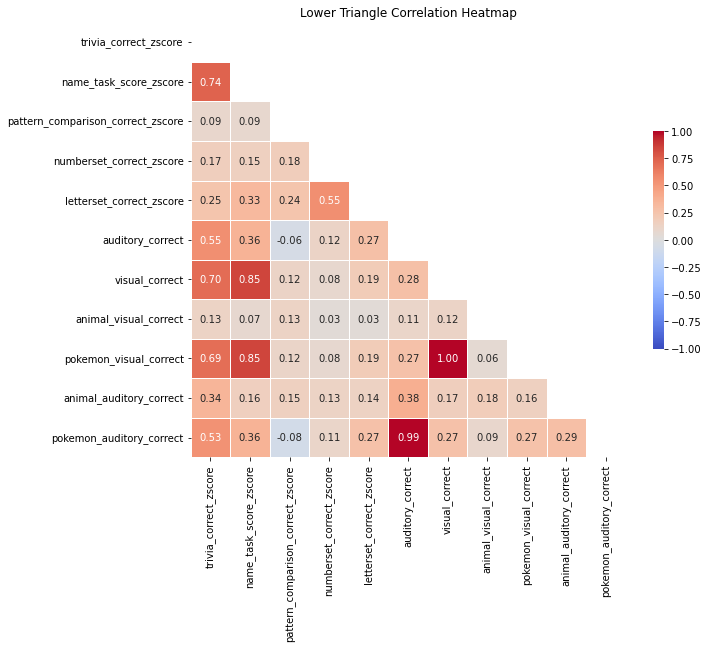

In [66]:
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,          
    cmap='coolwarm',  
    vmax=1,            
    vmin=-1,          
    center=0,          
    square=True,      
    linewidths=.5,     
    cbar_kws={"shrink": .5},
    annot=True,        
    fmt='.2f'           
)

plt.title('Lower Triangle Correlation Heatmap')
plt.show()

In [67]:
merged_grouped_df['pokemon_knowledge_composite_zscore'] = (merged_grouped_df['trivia_correct_zscore'] \
                                                           + merged_grouped_df['name_task_score_zscore']) / 2

In [68]:
merged_grouped_df['gf_composite_zscore'] = (merged_grouped_df['numberset_correct_zscore'] \
                                            + merged_grouped_df['letterset_correct_zscore']) / 2

## Create interaction terms by multiplying Pokémon knowledge composite by Gf composite; and Pokémon knowledge composite by pattern comparison (z).
PKxGf = PK z comp x Gf z comp

PKxPC = PK z comp x PC z


In [69]:
merged_grouped_df['PKxGf'] = merged_grouped_df['pokemon_knowledge_composite_zscore'] * \
                             merged_grouped_df['gf_composite_zscore']
merged_grouped_df['PKxPC'] = merged_grouped_df['pokemon_knowledge_composite_zscore'] * \
                             merged_grouped_df['pattern_comparison_correct_zscore']

In [70]:
merged_grouped_df.to_csv('cleaned_df_for_jasp_new.csv')

## For criterion measures (RT, accuracy for Pokémon and Animals recognition tasks), screen for outliers and replace outliers with +/- 3.5 raw score cutoff value (don’t z-transform, so that results can be interpreted in original units…or you could also z transform and then back-transform to original units).
Not sure whether we want to create composites for criterion tasks…we can figure this out later
